In [1]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import matplotlib.pyplot as plt

In [2]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\cfl602\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
df = pd.read_csv("../DataSets/amazon.csv")

In [4]:
reviews = df['reviewText'].dropna().astype(str).tolist()

In [5]:
# Initialize Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

In [6]:
positive_count = 0
negative_count = 0
neutral_count = 0

In [7]:
for review in reviews:
    score = sia.polarity_scores(review)
    if score['compound'] >= 0.05:
        positive_count += 1
    elif score['compound'] <= -0.05:
        negative_count += 1
    else:
        neutral_count += 1

In [8]:
total_reviews = len(reviews)
positive_percentage = (positive_count / total_reviews) * 100
negative_percentage = (negative_count / total_reviews) * 100
neutral_percentage = (neutral_count / total_reviews) * 100

print("Summary Report for Management")
print(f"Total Reviews: {total_reviews}")
print(f"Positive Reviews: {positive_percentage:.2f}%")
print(f"Negative Reviews: {negative_percentage:.2f}%")
print(f"Neutral Reviews: {neutral_percentage:.2f}%")

Summary Report for Management
Total Reviews: 20000
Positive Reviews: 77.53%
Negative Reviews: 18.29%
Neutral Reviews: 4.18%


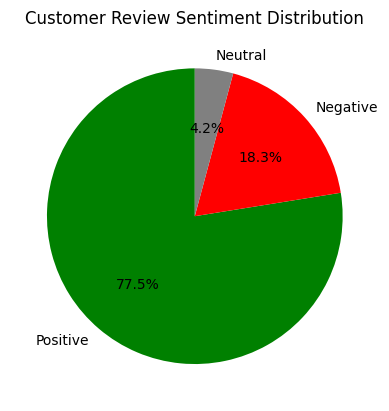

In [9]:
labels = ['Positive', 'Negative', 'Neutral']
sizes = [positive_count, negative_count, neutral_count]
colors = ['green', 'red', 'gray']

plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title("Customer Review Sentiment Distribution")
plt.show()